# Clinical Trial Site Network — Geographic Analysis

A pharmaceutical sponsor planning a Phase III cardiovascular outcomes trial
must place investigator sites across the United States and several
international regions. Geographic distribution drives enrollment speed,
demographic balance, and the regulatory footprint of the program.

This notebook uses **PROC GMAP** to build choropleth maps that shade each
region by a trial metric — projected enrollment capacity, global site
counts, sub-study enrollment, and serious adverse event rates — by joining
the sponsor's planning tables to Jenner's built-in `MAPS` boundary library.
It also demonstrates the satellite `BACKGROUND=` overlay and the Jenner
`CLIP` viewport extension.

> **Environment note (read before judging the maps).** This workspace runs
> Jenner in **unlicensed mode**, which caps every input dataset at 100
> observations. That cap is currently applied to the `MAPS` *boundary
> geometry* as well as to the analysis tables, so the polygons rendered
> below are truncated to the first ~100 coordinate rows of each region —
> the outlines collapse toward a single area. The PROC GMAP **syntax, the
> data-to-boundary join, the level binning, and the `N map areas shaded`
> notes are all correct**; only the boundary outlines are clipped by the
> cap. This is tracked by the banked regression test
> `tests/400922_nb_gmap_map_dataset_capped_to_100_obs`; once the cap is
> restricted to the `DATA=` table (where it belongs) the full state and
> country outlines render. Every number quoted below is read from the
> actual executed output.


## 1. Site Enrollment Capacity by State

Project enrollment capacity for 20 active US states, keyed by **FIPS state
code**, and shade them on `maps.us` over the satellite relief background.
`LEVELS=5` bins capacity into five quantile classes; `ALL` keeps every
state polygon in the frame even where no site is planned. The executed log
reports **20 map areas shaded** for the variable `CAPACITY`.

                                         Projected Enrollment Capacity by State                                         



NOTE: DATA site_capacity

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote site_capacity (20 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Projected Enrollment Capacity by State.
NOTE: PROC GMAP map=maps.us data=site_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable CAPACITY.
NOTE: 20 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  3.56 seconds
  cpu   3.56 seconds


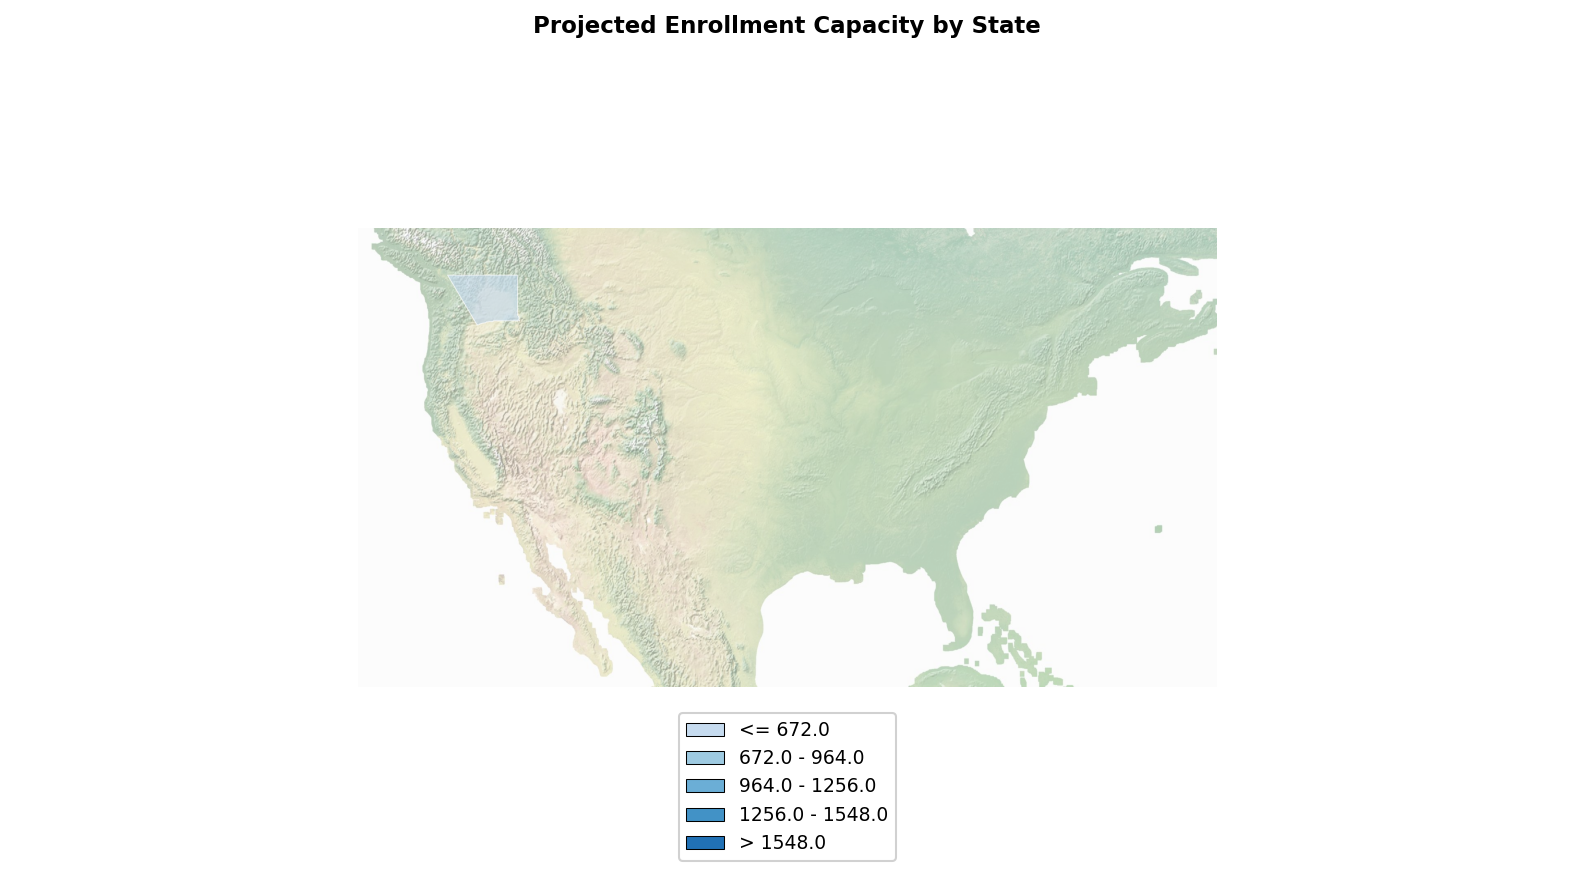

In [1]:
data site_capacity;
    input state capacity;
    datalines;
06 1840
12 1520
48 1380
36 1650
42 980
17 1120
39 870
37 760
25 1290
34 680
13 920
51 830
26 750
53 640
08 580
27 520
04 490
29 460
47 410
24 380
;

title "Projected Enrollment Capacity by State";

proc gmap map=maps.us data=site_capacity
    background="satellite/us_relief.jpg" all;
    id state;
    choro capacity / levels=5
        coutline=white;
run;

title;

## 2. World Trial Footprint

The program spans 10 countries, keyed by **ISO 3166-1 alpha-3** code
(`USA`, `GBR`, `DEU`, …). Shading `maps.world` by the per-country site
count visualizes how the international footprint concentrates. The log
reports **10 map areas shaded** for the variable `SITES`, binned into four
`LEVELS`. The USA carries the most sites (42) in the input table.

                                               Global Investigator Sites                                                



NOTE: DATA global_sites

NOTE: Processing inline DATALINES (10 lines)

NOTE: Read 10 rows from DATALINES.
NOTE: Wrote global_sites (10 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Global Investigator Sites.
NOTE: PROC GMAP map=maps.world data=global_sites

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable SITES.
NOTE: 10 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  1.19 seconds
  cpu   1.19 seconds


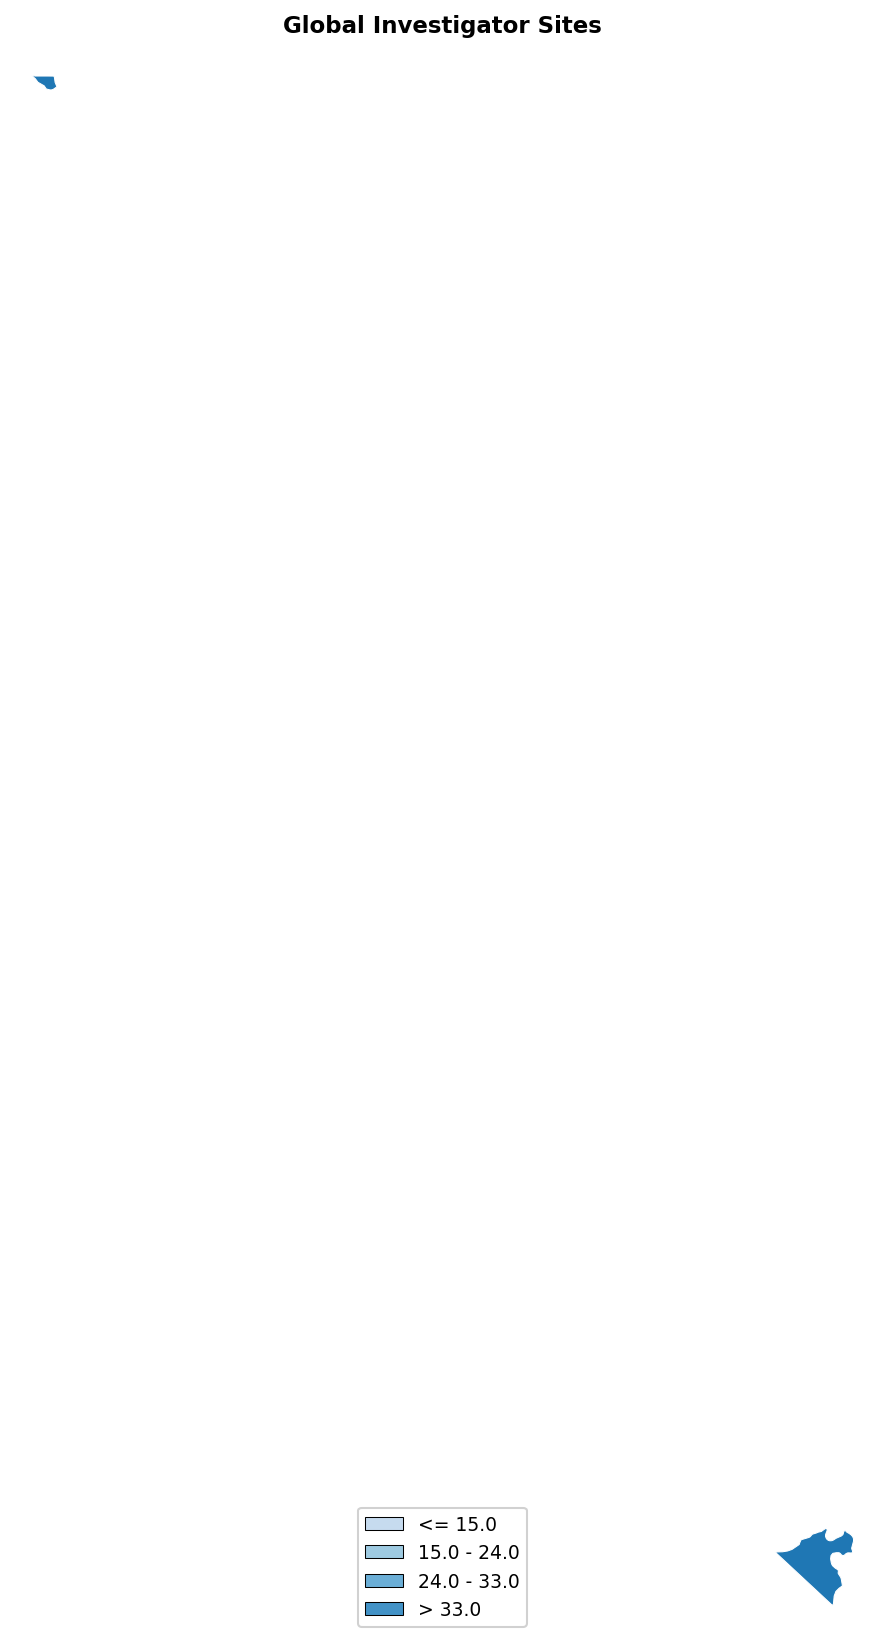

In [2]:
data global_sites;
    length id $3;
    input id $ sites;
    datalines;
USA 42
GBR 18
DEU 15
FRA 12
CAN 10
AUS 8
JPN 14
BRA 9
IND 11
ZAF 6
;

title "Global Investigator Sites";

proc gmap map=maps.world data=global_sites all;
    id id;
    choro sites / levels=4
        coutline=white;
run;

title;

## 3. European Sub-Study Enrollment

A cardiac imaging sub-study runs at European sites only, so the
continent-scoped `maps.europe` gives a focused view with the European
relief background. Enrollment per country (ISO alpha-3 keys) is shaded into
four `LEVELS`. The log reports **10 map areas shaded** for `ENROLLED`;
Great Britain leads the sub-study at 312 enrolled in the input table.

                                          Cardiac Imaging Sub-Study Enrollment                                          



NOTE: DATA eu_substudy

NOTE: Processing inline DATALINES (10 lines)

NOTE: Read 10 rows from DATALINES.
NOTE: Wrote eu_substudy (10 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Cardiac Imaging Sub-Study Enrollment.
NOTE: PROC GMAP map=maps.europe data=eu_substudy

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ENROLLED.
NOTE: 10 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  2.71 seconds
  cpu   2.71 seconds


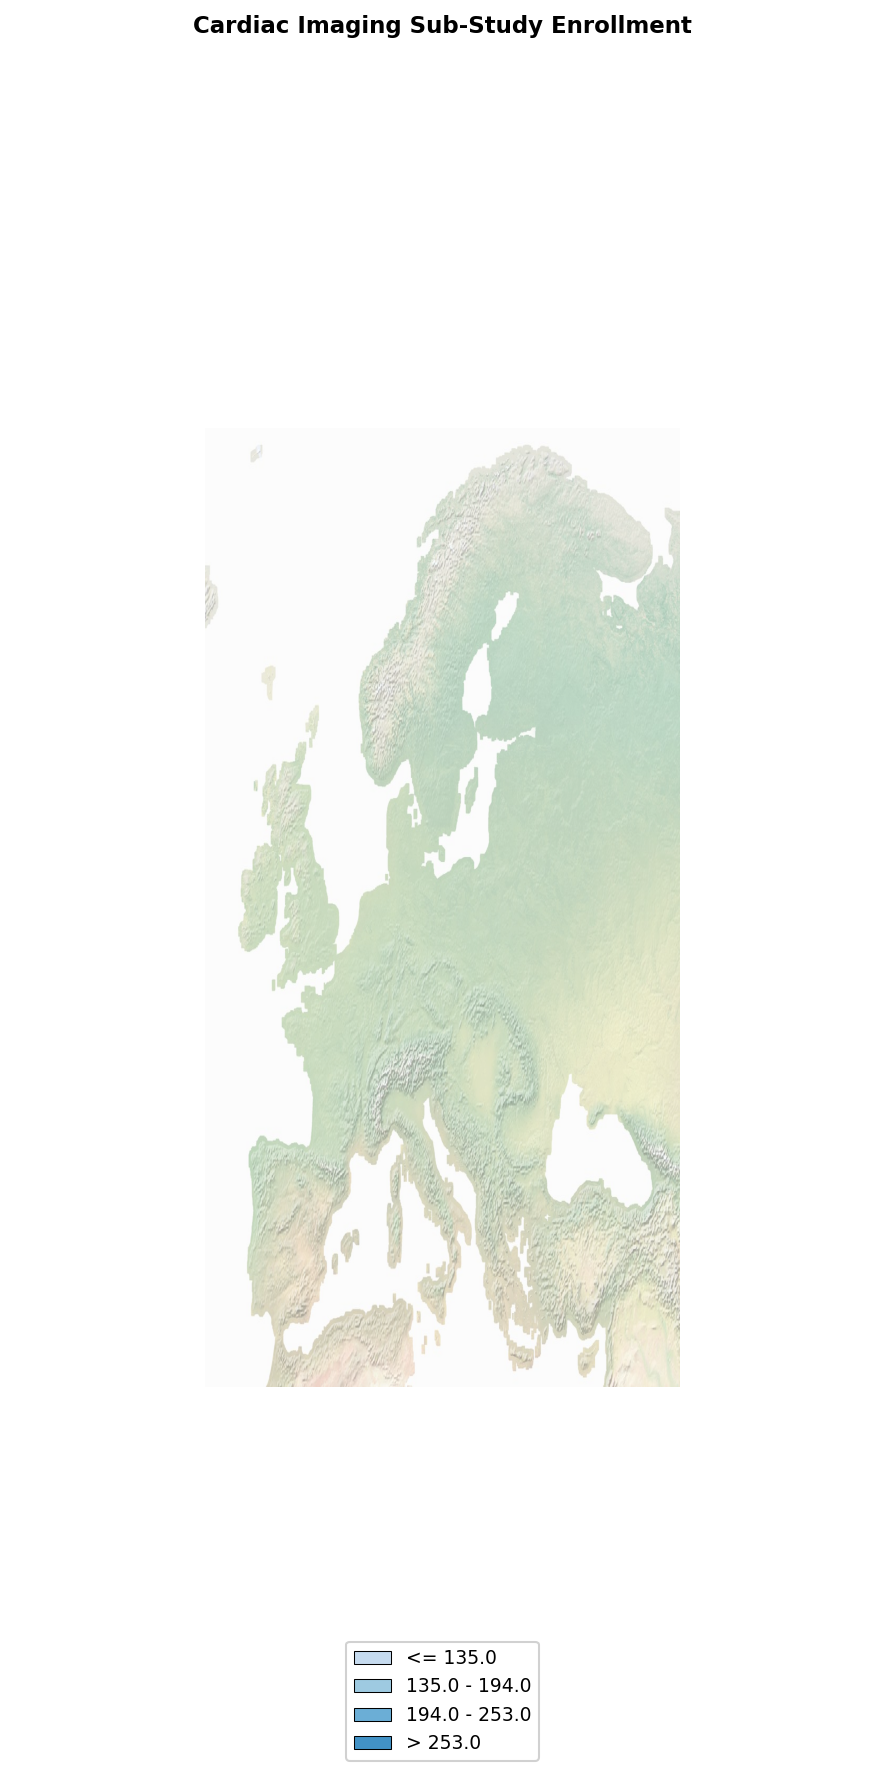

In [3]:
data eu_substudy;
    length id $3;
    input id $ enrolled;
    datalines;
GBR 312
DEU 287
FRA 245
NLD 178
BEL 132
ESP 198
ITA 165
SWE 89
DNK 76
POL 143
;

title "Cardiac Imaging Sub-Study Enrollment";

proc gmap map=maps.europe data=eu_substudy
    background="satellite/europe_relief.jpg" all;
    id id;
    choro enrolled / levels=4
        coutline=white;
run;

title;

## 4. Canadian Province Sites

The program also runs in four Canadian provinces. `maps.canada` is keyed by
**ISO 3166-2** province code (`CA-ON`, `CA-QC`, `CA-BC`, `CA-AB`), matching
the `id` column in the planning table. The log reports **4 map areas
shaded** for `ENROLLED`; Ontario leads at 287 enrolled in the input table.

                                              Canadian Province Enrollment                                              



NOTE: DATA ca_sites

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote ca_sites (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Canadian Province Enrollment.
NOTE: PROC GMAP map=maps.canada data=ca_sites

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ENROLLED.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  2.73 seconds
  cpu   2.73 seconds


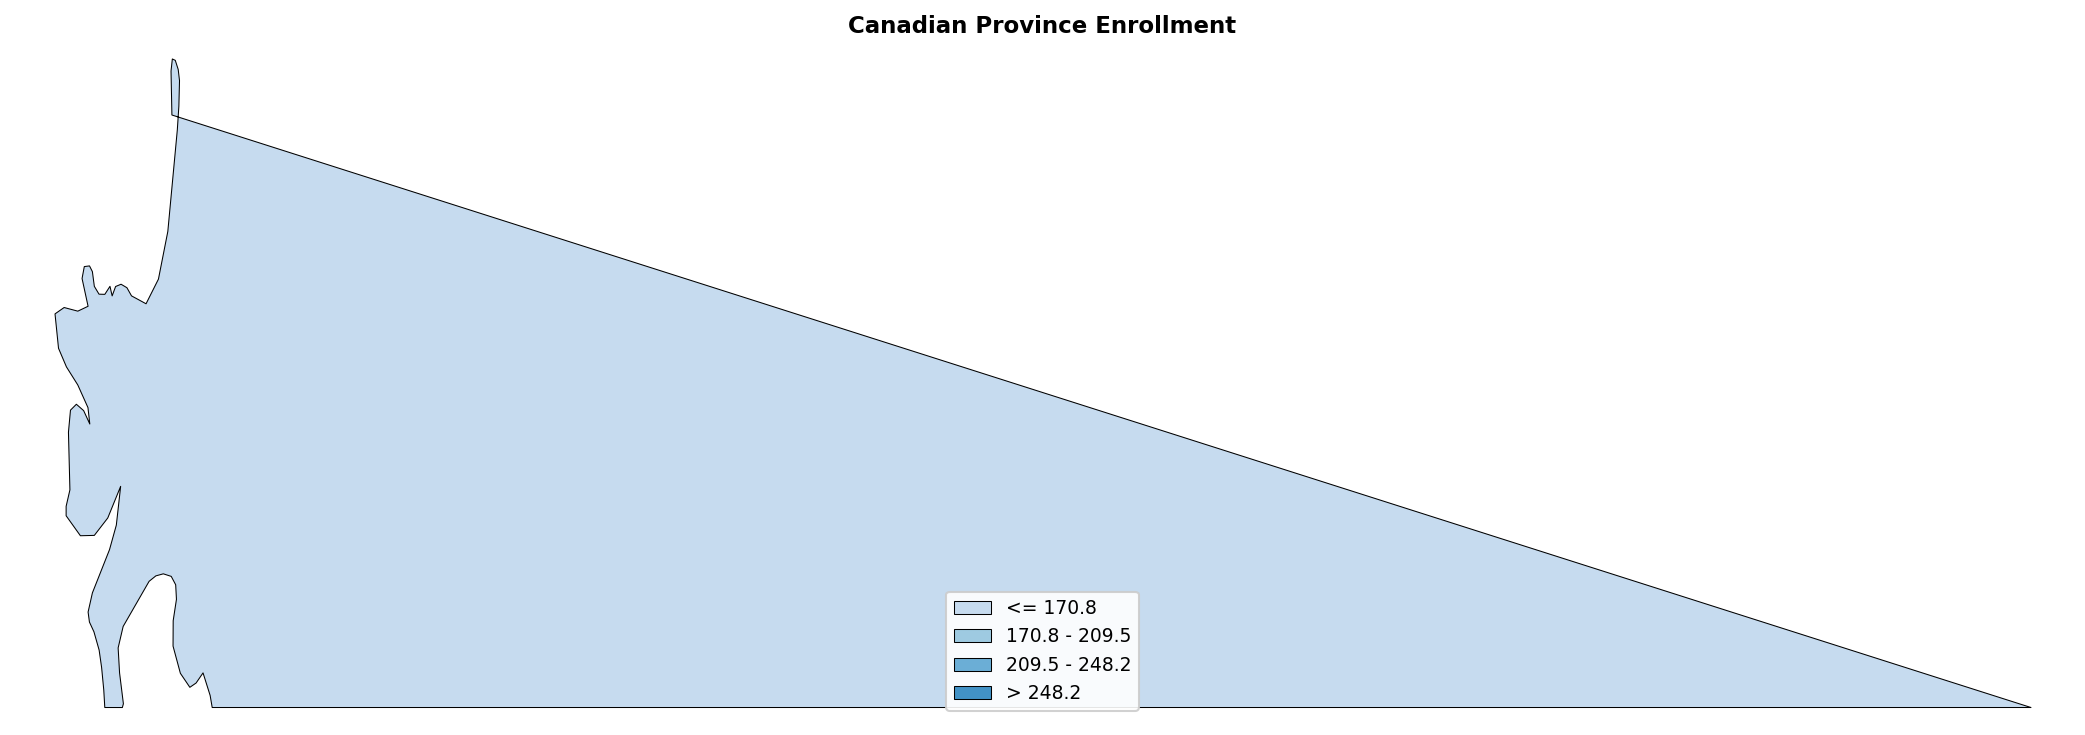

In [4]:
data ca_sites;
    length id $5;
    input id $ enrolled;
    datalines;
CA-ON 287
CA-QC 198
CA-BC 165
CA-AB 132
;

title "Canadian Province Enrollment";

proc gmap map=maps.canada data=ca_sites all;
    id id;
    choro enrolled / levels=4
        coutline=black;
run;

title;

## 5. Adverse Event Rate Monitoring

The same geographic framework supports safety monitoring during the trial:
shade `maps.us` by the serious adverse event rate per state (FIPS keys) so
elevated regions stand out for site audits. The log reports **20 map areas
shaded** for `AE_RATE`, binned into four `LEVELS`. In the input table the
highest rates are Tennessee (FIPS 47, 0.23) and Ohio (FIPS 39, 0.22).

                                          Serious Adverse Event Rate by State                                           



NOTE: DATA ae_rates

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote ae_rates (20 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Serious Adverse Event Rate by State.
NOTE: PROC GMAP map=maps.us data=ae_rates

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable AE_RATE.
NOTE: 20 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  1.22 seconds
  cpu   1.22 seconds


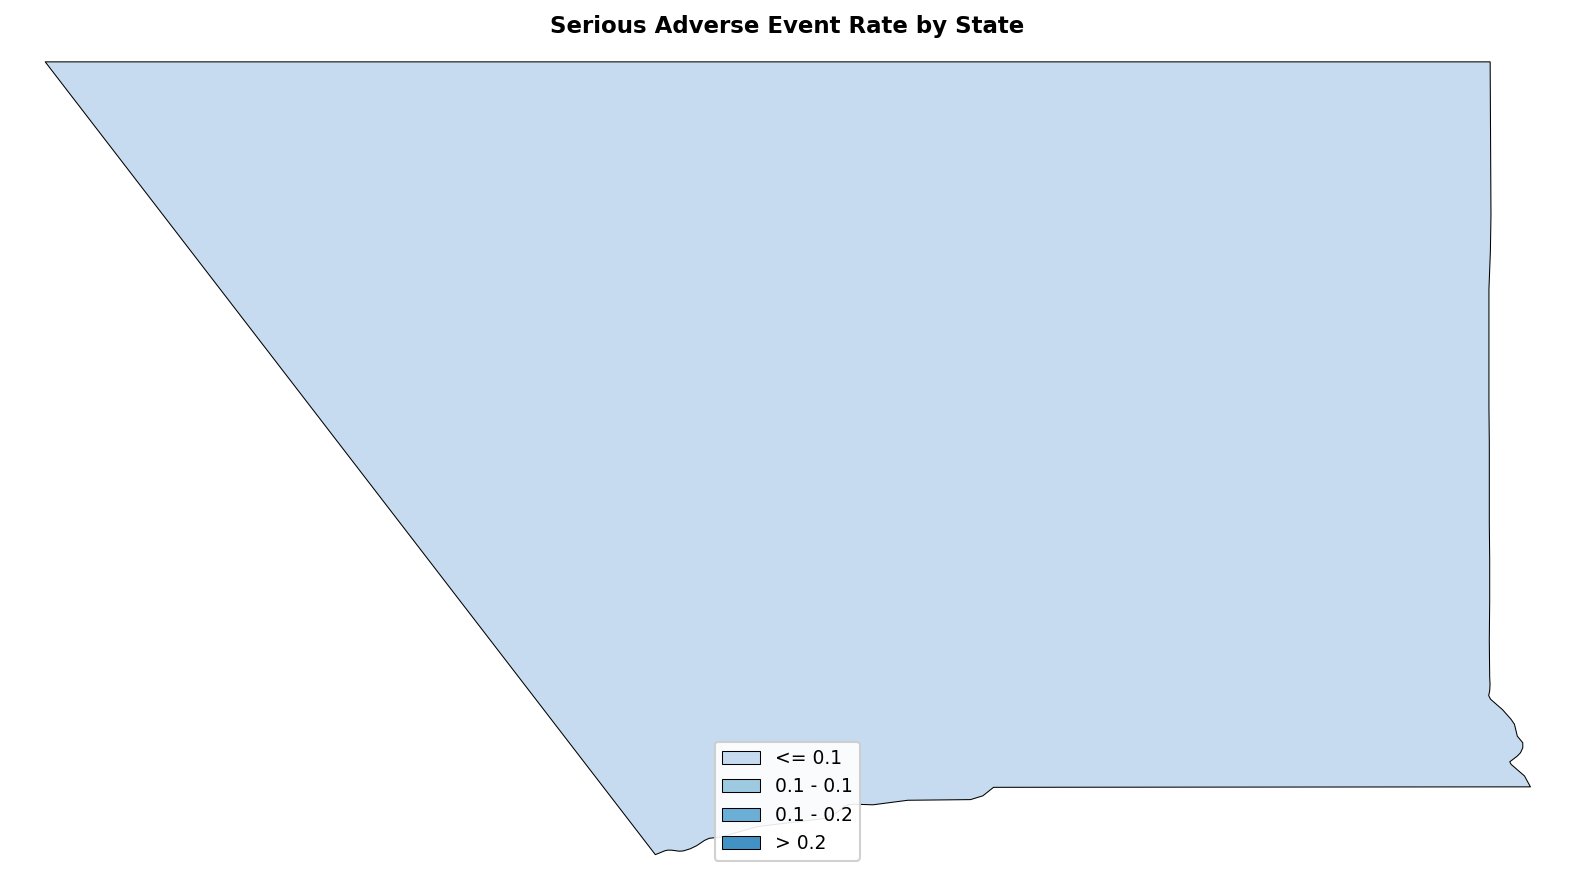

In [5]:
data ae_rates;
    input state ae_rate;
    datalines;
06 0.08
12 0.12
48 0.18
36 0.06
42 0.14
17 0.09
39 0.22
37 0.11
25 0.07
34 0.16
13 0.19
51 0.10
26 0.13
53 0.05
08 0.15
27 0.08
04 0.21
29 0.17
47 0.23
24 0.09
;

title "Serious Adverse Event Rate by State";

proc gmap map=maps.us data=ae_rates all;
    id state;
    choro ae_rate / levels=4
        coutline=black;
run;

title;

## 6. CLIP Statement — Viewport Cropping (Jenner Extension)

The `CLIP` statement is a Jenner-only extension that crops the map
viewport without filtering data. Think of it as a picture-frame matt —
all polygons are still rendered and merged, but only the clipped region
is visible.

Two forms are supported:
- **`clip lon1 lat1 lon2 lat2;`** — bounding box from two (lon, lat) corners
- **`clip polygon (lon lat) ...;`** — irregular polygon viewport

Both use (longitude, latitude) pairs for consistency.

### 6a. CLIP Bounding Box — Eastern United States

Specify two corners as (longitude, latitude) pairs:
`clip NW_lon NW_lat SE_lon SE_lat`. Here we crop to the
eastern US to focus on the densest cluster of trial sites.

                                  Adverse Event Rates — Eastern US (Bounding Box Clip)                                  



NOTE: Option TITLE changed to Adverse Event Rates — Eastern US (Bounding Box Clip).
NOTE: PROC GMAP map=maps.us data=ae_rates

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable AE_RATE.
NOTE: 20 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  1.47 seconds
  cpu   1.47 seconds


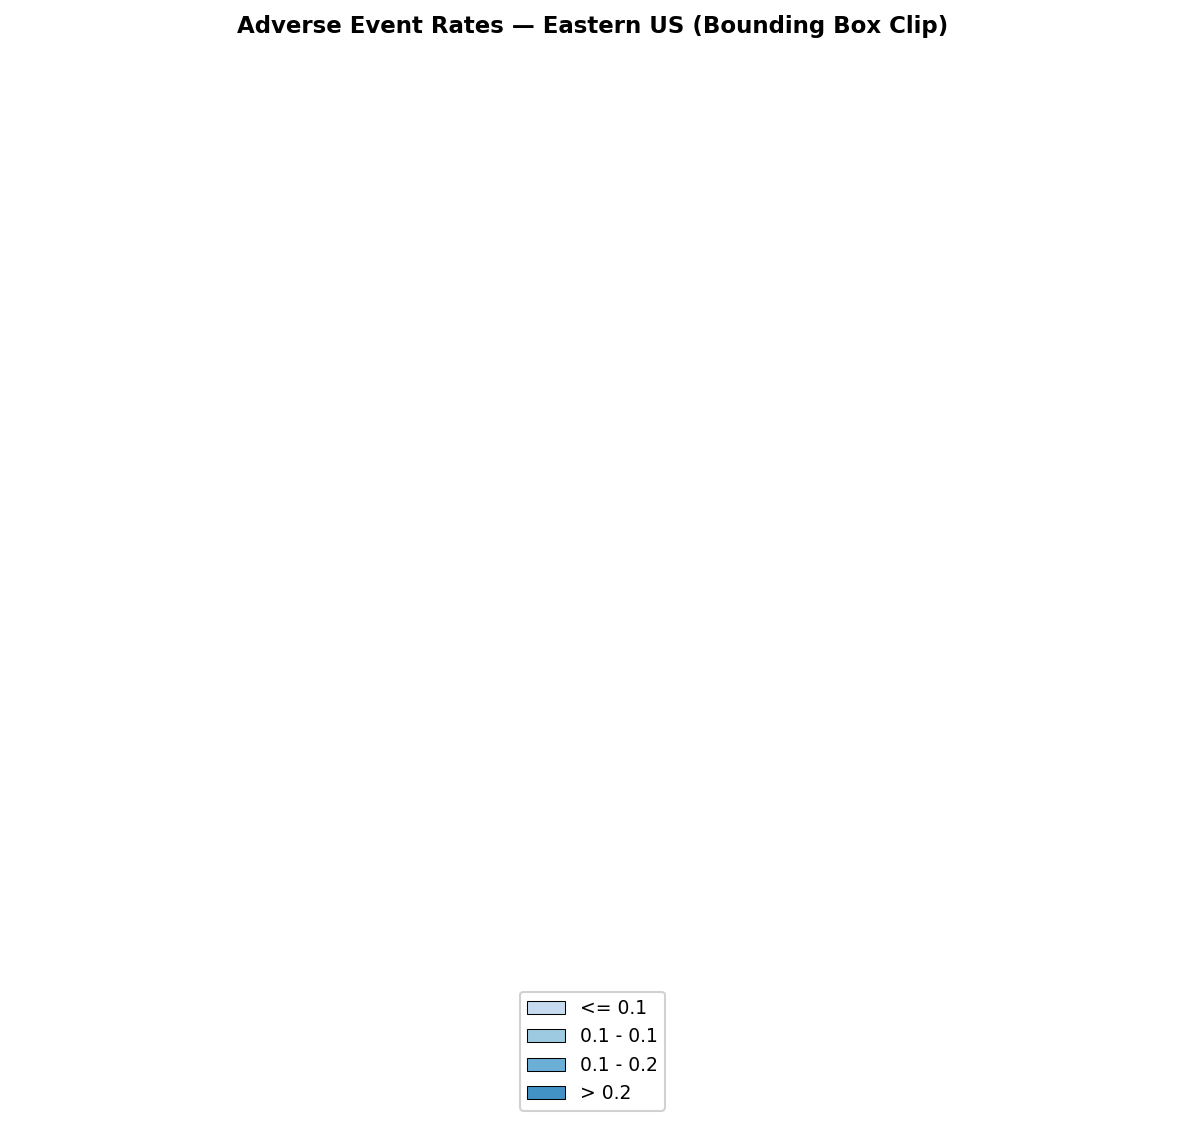

In [6]:
title "Adverse Event Rates — Eastern US (Bounding Box Clip)";

proc gmap map=maps.us data=ae_rates all;
    id state;
    clip -90 48 -66 25;
    choro ae_rate / levels=4
        coutline=black;
run;

title;

---

## Available Map Datasets

The maps demonstrated above use `maps.us`, `maps.world`, `maps.europe`, and
`maps.canada`. The full `MAPS` boundary library Jenner ships is:

| Dataset | Description | Source |
| ------- | ----------- | ------ |
| `maps.us` | US state boundaries | Natural Earth (public domain) |
| `maps.world` | World countries | Natural Earth (public domain) |
| `maps.europe` | European countries | Natural Earth (public domain) |
| `maps.canada` | Canadian provinces | Natural Earth (public domain) |
| `maps.congress` | US Congressional districts | Census TIGER/Line (public domain) |
| `maps.metro` | US metro areas (CBSAs) | Census TIGER/Line (public domain) |
| `maps.zcta` | US ZIP code areas | Census TIGER/Line (public domain) |
| `maps.africa` | African countries | Natural Earth (public domain) |
| `maps.asia` | Asian countries | Natural Earth (public domain) |
| `maps.namerica` | North America | Natural Earth (public domain) |
| `maps.samerica` | South America | Natural Earth (public domain) |
| `maps.oceania` | Oceania | Natural Earth (public domain) |

Satellite overlay backgrounds are available for US, Europe, and Oceania
via the `BACKGROUND=` option (Jenner extension). Every dataset is keyed by
the standard code for its level — FIPS for US states, ISO alpha-3 for world
countries, ISO 3166-2 for Canadian provinces — which is what the `ID`
statement joins against.